# Marketplace Product & Financial Analytics: Olist E-commerce Case

## Финальное резюме проекта

Этот ноутбук объединяет основные результаты end-to-end анализа данных маркетплейса Olist: продуктовые и финансовые метрики, поведение клиентов, retention и RFM-сегментацию, воронку привлечения продавцов, анализ клиентского опыта, ML-модель риска негативного отзыва и симуляцию A/B-теста.

Цель финального ноутбука — представить проект в компактном формате, подходящем для просмотра работодателем, публикации на GitHub и обсуждения на собеседовании.

В ноутбуке используются уже подготовленные результаты предыдущих этапов. Повторная реализация полного анализа и промежуточная исследовательская работа здесь не приводятся.

## Структура финального анализа

1. Контекст и бизнес-задачи проекта
2. Данные и аналитическая методология
3. Основные продуктовые и финансовые показатели
4. Динамика заказов, GMV и среднего чека
5. Анализ товарных категорий
6. Retention, RFM и ценность клиентов
7. Seller Marketing Funnel
8. Риск негативного клиентского опыта и ML-модель
9. Продуктовые гипотезы и симуляция A/B-теста
10. Итоговые бизнес-рекомендации
11. Ограничения анализа
12. Навыки, продемонстрированные в проекте

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

In [3]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

processed_data_path = project_root / "data" / "processed"
reports_path = project_root / "reports"

project_root

WindowsPath('D:/olist-marketplace-product-analytics')

## 2. Данные и аналитическая методология

Проект основан на двух открытых наборах данных Olist:

- **Brazilian E-Commerce Public Dataset** — заказы, клиенты, товары, продавцы, платежи, доставка и отзывы;
- **Marketing Funnel by Olist** — маркетинговые лиды и закрытые сделки по привлечению продавцов.

Исходные таблицы имеют разные уровни детализации. Например, один заказ может содержать несколько товарных позиций, платежей и отзывов. Поэтому перед расчётом метрик таблицы были агрегированы до необходимого уровня, чтобы избежать размножения строк и завышения финансовых показателей.

Основные методологические решения:

- базовая аналитическая витрина содержит одну строку на заказ;
- основные KPI рассчитываются по доставленным заказам;
- `GMV` определяется как стоимость товаров без доставки;
- стоимость доставки анализируется отдельно;
- для идентификации покупателей используется `customer_unique_id`;
- LTV рассчитывается только как proxy через накопленный GMV клиента;
- seller funnel рассматривается как воронка привлечения продавцов, а не покупателей;
- наблюдательные зависимости не интерпретируются как причинные;
- A/B-анализ выполнен в форме синтетической симуляции, поскольку реальных экспериментальных групп в данных нет;
- ML-выборка разделена по времени, а признаки с утечкой целевой переменной исключены.

In [4]:
orders_base = pd.read_csv(
    processed_data_path / "orders_base.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

rfm_segments = pd.read_csv(
    processed_data_path / "rfm_segments.csv"
)

funnel_seller_value = pd.read_csv(
    processed_data_path / "funnel_seller_value.csv"
)

model_results = pd.read_csv(
    reports_path / "model_results.csv"
)

print(f"orders_base: {orders_base.shape}")
print(f"rfm_segments: {rfm_segments.shape}")
print(f"funnel_seller_value: {funnel_seller_value.shape}")
print(f"model_results: {model_results.shape}")

orders_base: (99441, 33)
rfm_segments: (93358, 14)
funnel_seller_value: (842, 24)
model_results: (2, 14)


## 3. Основные продуктовые и финансовые показатели

Основные показатели маркетплейса рассчитываются по доставленным заказам. Такой подход исключает отменённые, недоступные и незавершённые заказы и позволяет оценивать фактически реализованный товарный оборот.

В проекте используются следующие определения:

* **GMV** — суммарная стоимость товаров без доставки;
* **AOV** — средний GMV на один доставленный заказ;
* **freight value** — суммарная стоимость доставки;
* **repeat customer rate** — доля клиентов, совершивших более одного доставленного заказа;
* **average review score** — средняя оценка по заказам, для которых был оставлен отзыв.


In [5]:
delivered_orders = orders_base.loc[
    orders_base["order_status"].eq("delivered")
].copy()

customer_order_counts = (
    delivered_orders.groupby("customer_unique_id")["order_id"]
    .nunique()
)

kpi_summary = pd.Series(
    {
        "Delivered orders": delivered_orders["order_id"].nunique(),
        "Unique customers": delivered_orders["customer_unique_id"].nunique(),
        "GMV": delivered_orders["gmv"].sum(),
        "Freight value": delivered_orders["freight_value"].sum(),
        "AOV": delivered_orders["gmv"].mean(),
        "Average review score": delivered_orders["review_score"].mean(),
        "Repeat customer rate": customer_order_counts.gt(1).mean(),
    },
    name="Value",
).to_frame()

kpi_summary

,Value
Delivered orders,"96,478.00"
Unique customers,"93,358.00"
GMV,"13,221,498.11"
Freight value,"2,198,275.64"
AOV,137.04
Average review score,4.16
Repeat customer rate,0.03


In [6]:
kpi_display = pd.DataFrame(
    {
        "Метрика": [
            "Доставленные заказы",
            "Уникальные клиенты",
            "GMV",
            "Стоимость доставки",
            "Средний чек, AOV",
            "Средняя оценка",
            "Доля повторных клиентов",
        ],
        "Значение": [
            f"{delivered_orders['order_id'].nunique():,.0f}",
            f"{delivered_orders['customer_unique_id'].nunique():,.0f}",
            f"{delivered_orders['gmv'].sum():,.2f}",
            f"{delivered_orders['freight_value'].sum():,.2f}",
            f"{delivered_orders['gmv'].mean():,.2f}",
            f"{delivered_orders['review_score'].mean():.2f}",
            f"{customer_order_counts.gt(1).mean():.2%}",
        ],
    }
)

kpi_display

,Метрика,Значение
0,Доставленные заказы,"96,478"
1,Уникальные клиенты,"93,358"
2,GMV,"13,221,498.11"
3,Стоимость доставки,"2,198,275.64"
4,"Средний чек, AOV",137.04
5,Средняя оценка,4.16
6,Доля повторных клиентов,3.00%


### Интерпретация основных показателей

За рассматриваемый период маркетплейс обработал **96 478 доставленных заказов** от **93 358 уникальных покупателей**. Совокупный GMV составил **13,22 млн**, а средний товарный чек — **137,04**.

Стоимость доставки составила **2,20 млн**, однако она анализируется отдельно и не включается в GMV. Такое разделение позволяет не смешивать стоимость проданных товаров с логистическими платежами.

Средняя оценка доставленных заказов составила **4,16 из 5**, что указывает на преимущественно положительный клиентский опыт. При этом среднее значение скрывает отдельные проблемные сегменты, связанные с задержками доставки и сложными заказами, которые рассматриваются далее.

Доля клиентов, совершивших более одной покупки, составляет около **3%**. Это один из ключевых продуктовых сигналов проекта: большинство покупателей совершают только один заказ, поэтому развитие повторных покупок и удержания может быть важным направлением роста.

Следует учитывать, что показатели рассчитаны только по доставленным заказам, а GMV является показателем товарного оборота, но не выручкой или прибылью маркетплейса, поскольку данные о комиссии, марже и себестоимости отсутствуют.


## 4. Динамика заказов, GMV и среднего чека

Анализ месячной динамики позволяет определить, за счёт чего менялся товарный оборот маркетплейса: количества заказов или среднего чека.

Перед построением графиков необходимо проверить полноту крайних месяцев. Неполные периоды могут создавать искусственное снижение показателей и приводить к неправильным бизнес-выводам.


In [7]:
delivered_orders["order_month"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_metrics = (
    delivered_orders
    .groupby("order_month", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        gmv=("gmv", "sum"),
        aov=("gmv", "mean"),
        average_review_score=("review_score", "mean"),
    )
    .sort_values("order_month")
)

monthly_metrics

,order_month,orders,gmv,aov,average_review_score
0,2016-09-01,1,134.97,134.97,1.00
1,2016-10-01,265,"40,325.11",152.17,4.01
2,2016-12-01,1,10.90,10.90,5.00
3,2017-01-01,750,"111,798.36",149.06,4.20
4,2017-02-01,1653,"234,223.40",141.70,4.20
5,2017-03-01,2546,"359,198.85",141.08,4.19
6,2017-04-01,2303,"340,669.68",147.92,4.14
7,2017-05-01,3546,"489,338.25",138.00,4.24
8,2017-06-01,3135,"421,923.37",134.58,4.22
9,2017-07-01,3872,"481,604.52",124.38,4.26


In [8]:
monthly_metrics_plot = monthly_metrics.loc[
    monthly_metrics["order_month"].between("2017-01-01", "2018-08-01")
].copy()

monthly_metrics_plot

,order_month,orders,gmv,aov,average_review_score
3,2017-01-01,750,"111,798.36",149.06,4.20
4,2017-02-01,1653,"234,223.40",141.70,4.20
5,2017-03-01,2546,"359,198.85",141.08,4.19
6,2017-04-01,2303,"340,669.68",147.92,4.14
7,2017-05-01,3546,"489,338.25",138.00,4.24
8,2017-06-01,3135,"421,923.37",134.58,4.22
9,2017-07-01,3872,"481,604.52",124.38,4.26
10,2017-08-01,4193,"554,699.70",132.29,4.31
11,2017-09-01,4150,"607,399.67",146.36,4.27
12,2017-10-01,4478,"648,247.65",144.76,4.21


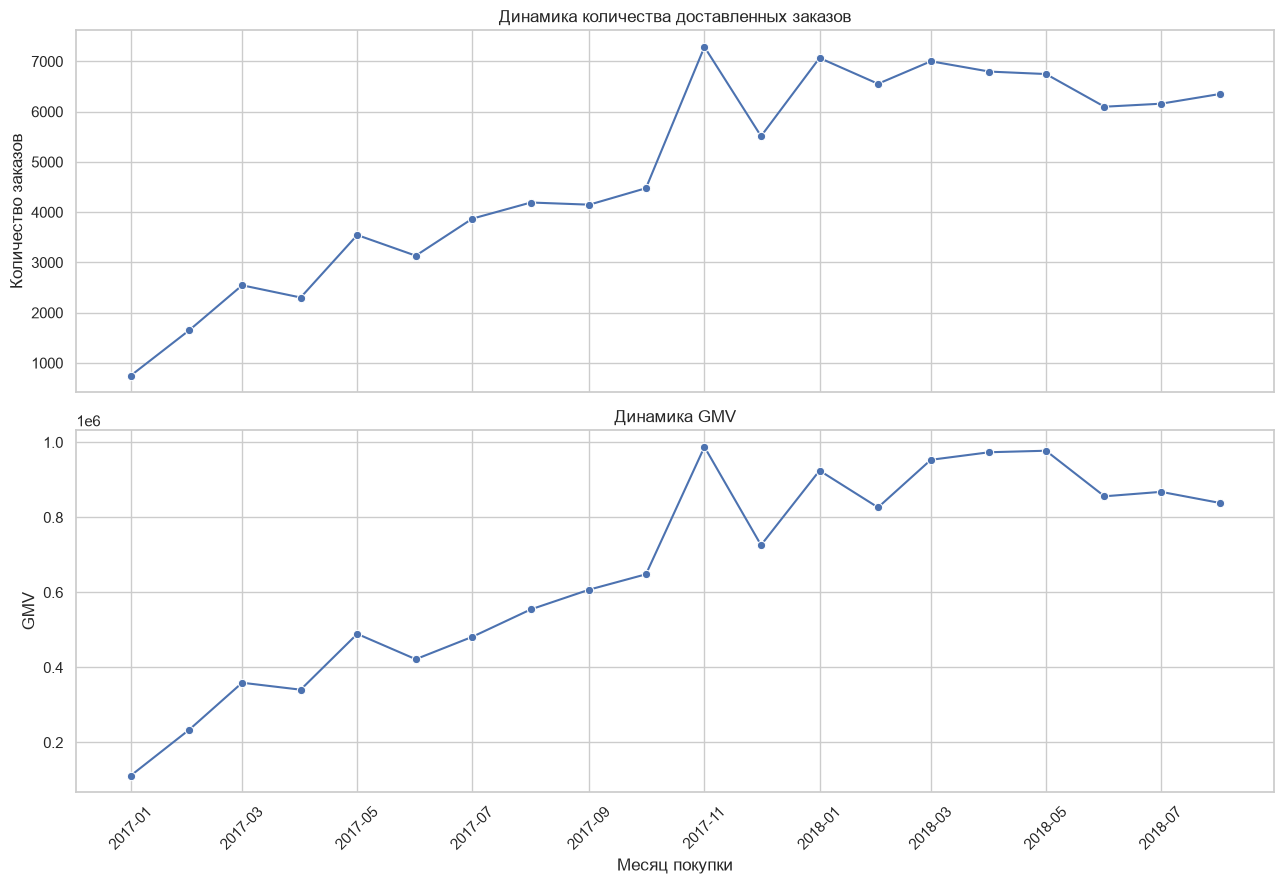

In [9]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 9),
    sharex=True,
)

sns.lineplot(
    data=monthly_metrics_plot,
    x="order_month",
    y="orders",
    marker="o",
    ax=axes[0],
)

axes[0].set_title("Динамика количества доставленных заказов")
axes[0].set_xlabel("")
axes[0].set_ylabel("Количество заказов")

sns.lineplot(
    data=monthly_metrics_plot,
    x="order_month",
    y="gmv",
    marker="o",
    ax=axes[1],
)

axes[1].set_title("Динамика GMV")
axes[1].set_xlabel("Месяц покупки")
axes[1].set_ylabel("GMV")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

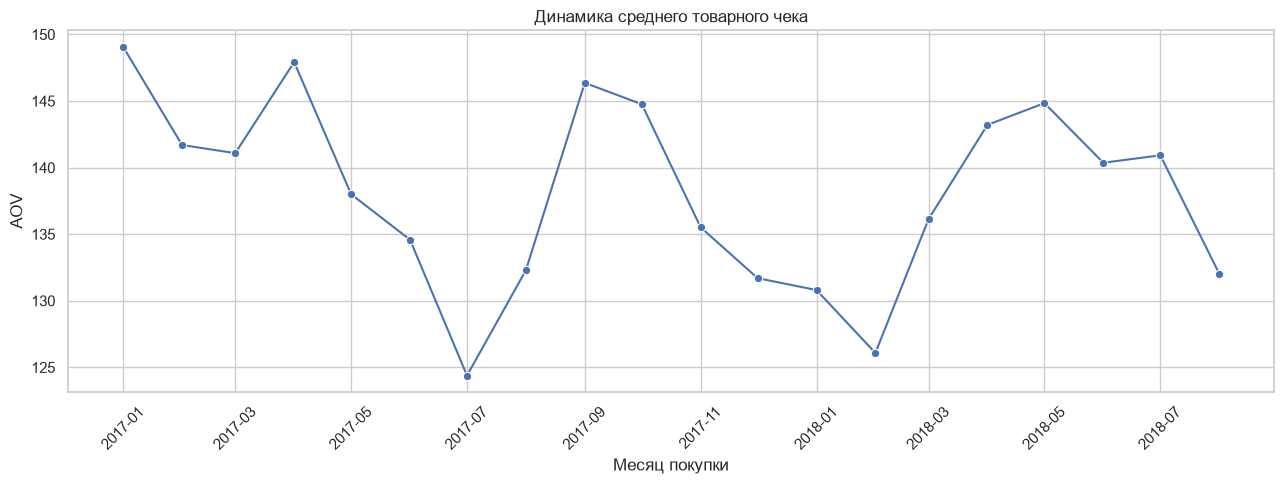

In [10]:
plt.figure(figsize=(13, 5))

sns.lineplot(
    data=monthly_metrics_plot,
    x="order_month",
    y="aov",
    marker="o",
)

plt.title("Динамика среднего товарного чека")
plt.xlabel("Месяц покупки")
plt.ylabel("AOV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

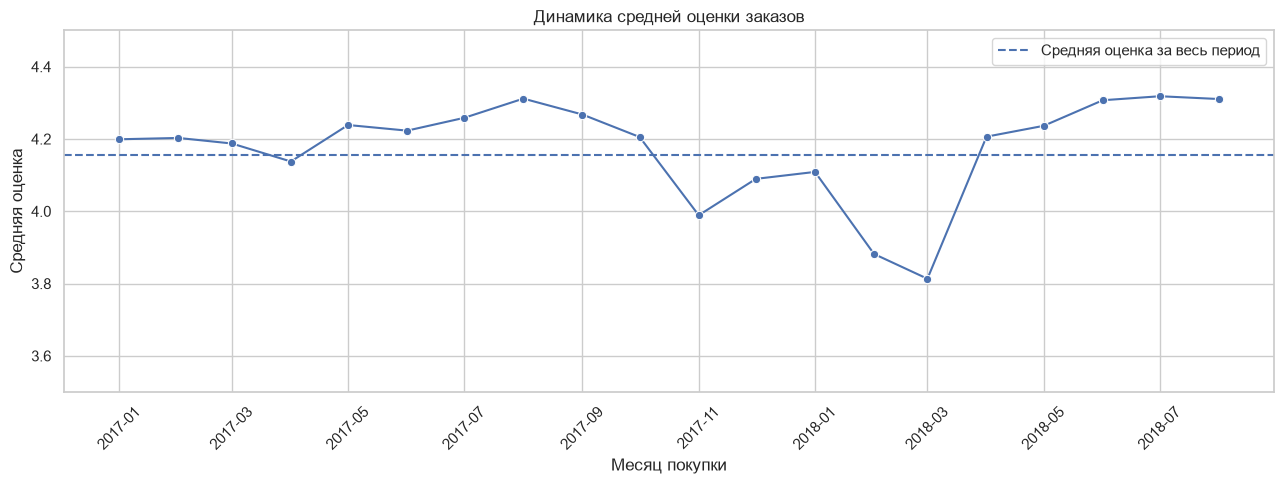

In [11]:
plt.figure(figsize=(13, 5))

sns.lineplot(
    data=monthly_metrics_plot,
    x="order_month",
    y="average_review_score",
    marker="o",
)

plt.axhline(
    delivered_orders["review_score"].mean(),
    linestyle="--",
    label="Средняя оценка за весь период",
)

plt.title("Динамика средней оценки заказов")
plt.xlabel("Месяц покупки")
plt.ylabel("Средняя оценка")
plt.ylim(3.5, 4.5)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Интерпретация динамики

С января по ноябрь 2017 года количество доставленных заказов и GMV заметно выросли. Максимальное количество заказов наблюдалось в ноябре 2017 года — **7 289 заказов**, что может быть связано с сезонным ростом спроса и периодом крупных распродаж. Однако без дополнительных данных о промоакциях и маркетинговых кампаниях подтвердить конкретную причину нельзя.

После снижения в декабре объём заказов восстановился в январе 2018 года. В течение большей части 2018 года маркетплейс сохранял относительно стабильный высокий уровень — около 6–7 тысяч доставленных заказов в месяц.

Динамика GMV в целом повторяет динамику количества заказов. При этом средний чек колебался примерно от **124 до 149**, но не демонстрировал устойчивого восходящего тренда. Следовательно, рост товарного оборота происходил преимущественно за счёт увеличения количества заказов, а не систематического роста стоимости одного заказа.

Средняя оценка заметно снизилась в феврале–марте 2018 года — до **3,88** и **3,81**, после чего восстановилась выше 4,2. Это указывает на временное ухудшение клиентского опыта и требует анализа логистики, задержек и структуры заказов в соответствующий период.

Данные 2016 года исключены из презентационной динамики, поскольку этот период содержит единичные и несопоставимые по объёму наблюдения.

In [12]:
print("Колонки orders_base:")
display(pd.Series(orders_base.columns, name="column"))

print("\nФайлы в data/raw:")
raw_files = sorted(
    file.name
    for file in (project_root / "data" / "raw").glob("*.csv")
)

raw_files

Колонки orders_base:


0                          order_id
1                       customer_id
2                      order_status
3          order_purchase_timestamp
4                 order_approved_at
5      order_delivered_carrier_date
6     order_delivered_customer_date
7     order_estimated_delivery_date
8                customer_unique_id
9          customer_zip_code_prefix
10                    customer_city
11                   customer_state
12                      items_count
13                   products_count
14                    sellers_count
15                  product_revenue
16                    freight_value
17                    payment_value
18             payment_installments
19              payment_types_count
20            payment_records_count
21                     review_score
22             review_records_count
23       first_review_creation_date
24     last_review_answer_timestamp
25                              gmv
26         order_value_with_freight
27                    delive


Файлы в data/raw:


['olist_closed_deals_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_marketing_qualified_leads_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

## 5. Анализ товарных категорий

Для анализа категорий используется таблица товарных позиций `order_items`, поскольку одна строка витрины `orders_base` может содержать товары нескольких категорий.

Прямое присоединение order-level GMV к товарным строкам привело бы к задвоению оборота. Поэтому GMV категории рассчитывается как сумма `price` товарных позиций, а показатели заказа и отзыва предварительно приводятся к уровню `order_id + category`.

In [13]:
order_items = pd.read_csv(
    project_root / "data" / "raw" / "olist_order_items_dataset.csv",
    usecols=[
        "order_id",
        "order_item_id",
        "product_id",
        "price",
        "freight_value",
    ],
)

products = pd.read_csv(
    project_root / "data" / "raw" / "olist_products_dataset.csv",
    usecols=[
        "product_id",
        "product_category_name",
    ],
)

category_translation = pd.read_csv(
    project_root / "data" / "raw" / "product_category_name_translation.csv"
)

category_items = (
    order_items
    .merge(
        products,
        on="product_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left",
        validate="many_to_one",
    )
)

category_name_mapping = {
    "pc_gamer": "pc_gaming",
    "portateis_cozinha_e_preparadores_de_alimentos":
        "portable_kitchen_and_food_preparation",
}

category_items["category"] = (
    category_items["product_category_name_english"]
    .fillna(category_items["product_category_name"])
    .fillna("unknown")
    .replace(category_name_mapping)
)

print(f"Товарных строк: {len(category_items):,}")
print(f"Уникальных заказов: {category_items['order_id'].nunique():,}")
print(f"Уникальных категорий: {category_items['category'].nunique():,}")
print(
    "Строк с неизвестной категорией:",
    f"{category_items['category'].eq('unknown').sum():,}",
)

category_items.head()

Товарных строк: 112,650
Уникальных заказов: 98,666
Уникальных категорий: 74
Строк с неизвестной категорией: 1,603


,order_id,order_item_id,product_id,price,freight_value,product_category_name,product_category_name_english,category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,cool_stuff,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,pet_shop,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,moveis_decoracao,furniture_decor,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,12.99,12.79,perfumaria,perfumery,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,199.90,18.14,ferramentas_jardim,garden_tools,garden_tools


In [14]:
order_category = (
    category_items
    .groupby(
        ["order_id", "category"],
        as_index=False,
    )
    .agg(
        category_items_count=("order_item_id", "count"),
        category_products_count=("product_id", "nunique"),
        category_gmv=("price", "sum"),
        category_freight_value=("freight_value", "sum"),
    )
    .merge(
        orders_base[
            [
                "order_id",
                "order_status",
                "order_purchase_timestamp",
                "customer_unique_id",
                "review_score",
                "is_delivered",
            ]
        ],
        on="order_id",
        how="left",
        validate="many_to_one",
    )
)

delivered_order_category = order_category.loc[
    order_category["is_delivered"]
].copy()

category_summary = (
    delivered_order_category
    .groupby("category", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        gmv=("category_gmv", "sum"),
        freight_value=("category_freight_value", "sum"),
        average_review_score=("review_score", "mean"),
    )
)

category_summary["aov_proxy"] = (
    category_summary["gmv"]
    / category_summary["orders"]
)

category_summary["freight_share"] = (
    category_summary["freight_value"]
    / (
        category_summary["gmv"]
        + category_summary["freight_value"]
    )
)

category_summary = (
    category_summary
    .sort_values("gmv", ascending=False)
    .reset_index(drop=True)
)

abc_categories = (
    category_summary.loc[
        ~category_summary["category"].eq("unknown")
    ]
    .sort_values("gmv", ascending=False)
    .reset_index(drop=True)
    .copy()
)

abc_categories["gmv_share"] = (
    abc_categories["gmv"]
    / abc_categories["gmv"].sum()
)

abc_categories["cumulative_gmv_share"] = (
    abc_categories["gmv_share"].cumsum()
)

previous_cumulative_share = (
    abc_categories["cumulative_gmv_share"]
    - abc_categories["gmv_share"]
)

abc_categories["abc_class"] = np.select(
    [
        previous_cumulative_share < 0.80,
        previous_cumulative_share < 0.95,
    ],
    ["A", "B"],
    default="C",
)

abc_summary = (
    abc_categories
    .groupby("abc_class", as_index=False)
    .agg(
        categories=("category", "nunique"),
        gmv=("gmv", "sum"),
    )
)

abc_summary["gmv_share"] = (
    abc_summary["gmv"]
    / abc_categories["gmv"].sum()
)

display(
    category_summary.loc[
        category_summary["category"].isin(
            [
                "pc_gaming",
                "portable_kitchen_and_food_preparation",
            ]
        )
    ]
)

display(abc_summary.sort_values("abc_class"))

,category,orders,gmv,freight_value,average_review_score,aov_proxy,freight_share
62,portable_kitchen_and_food_preparation,13,"3,933.63",294.42,3.62,302.59,0.07
68,pc_gaming,7,"1,306.95",123.15,3.43,186.71,0.09


,abc_class,categories,gmv,gmv_share
0,A,17,"10,535,883.37",0.81
1,B,16,"1,884,710.33",0.14
2,C,40,"630,177.78",0.05


In [15]:
category_gmv_total = (
    delivered_order_category["category_gmv"].sum()
)

orders_base_gmv_total = delivered_orders.loc[
    delivered_orders["order_id"].isin(
        delivered_order_category["order_id"]
    ),
    "gmv",
].sum()

gmv_difference = (
    category_gmv_total - orders_base_gmv_total
)

print(f"GMV категорий: {category_gmv_total:,.2f}")
print(f"GMV из orders_base: {orders_base_gmv_total:,.2f}")
print(f"Разница GMV: {gmv_difference:,.6f}")

GMV категорий: 13,221,498.11
GMV из orders_base: 13,221,498.11
Разница GMV: 0.000000


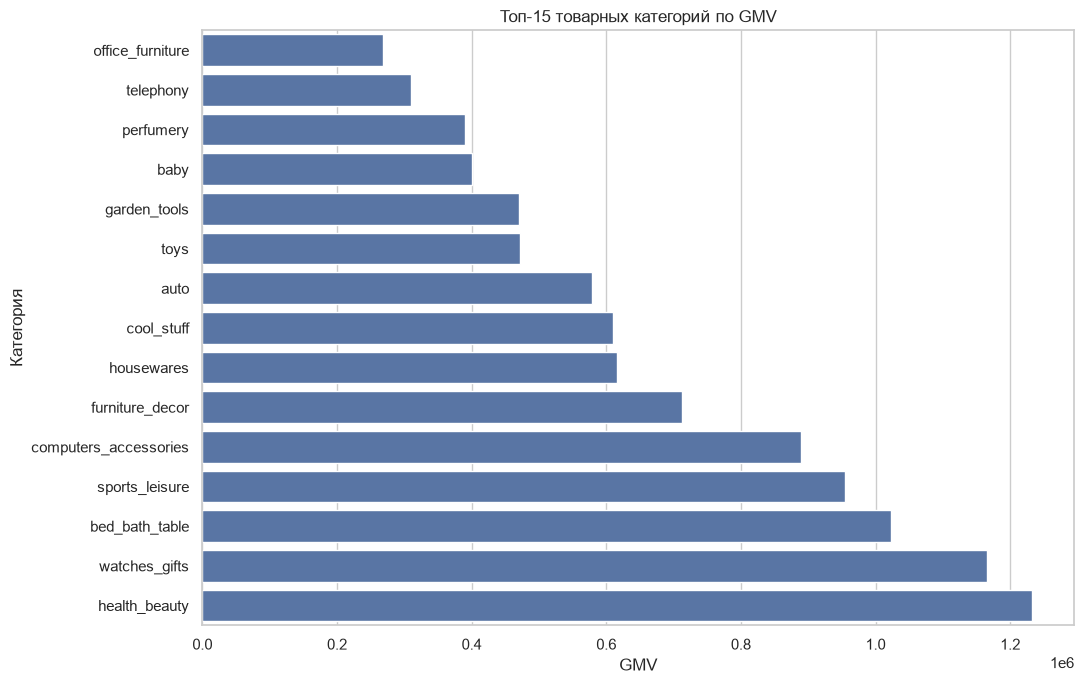

In [16]:
top_categories_by_gmv = (
    category_summary.loc[
        ~category_summary["category"].eq("unknown")
    ]
    .nlargest(15, "gmv")
    .sort_values("gmv")
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_categories_by_gmv,
    x="gmv",
    y="category",
)

plt.title("Топ-15 товарных категорий по GMV")
plt.xlabel("GMV")
plt.ylabel("Категория")
plt.tight_layout()
plt.show()

### Интерпретация категорий и ABC-анализа

Товарный оборот маркетплейса заметно сконцентрирован в ограниченном числе категорий. Класс A включает **17 категорий**, которые формируют около **81% GMV**. Классы B и C включают значительно больше категорий, но дают только около **19% совокупного оборота**.

Крупнейшими категориями по GMV являются `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure` и `computers_accessories`. Это означает, что изменения спроса, ассортимента или качества исполнения в этих категориях могут существенно влиять на общий результат маркетплейса.

Особого внимания требует категория `office_furniture`. Она сочетает:

- высокий `aov_proxy` — около **213,84**;
- высокую долю стоимости доставки — около **20%**;
- низкую среднюю оценку — около **3,64**.

Такое сочетание указывает на потенциальную проблему в клиентском опыте: дорогие и логистически сложные заказы могут чаще сталкиваться с задержками, повреждениями или несоответствием ожиданиям.

ABC-анализ можно использовать для приоритизации решений:

- категории A — основной фокус коммерческого и операционного контроля;
- категории B — зона потенциального роста;
- категории C — длинный хвост ассортимента, который требует оценки эффективности поддержки и логистики.

Техническая категория `unknown` исключена из бизнес-сравнения, но сохранена при сверке общего GMV, чтобы не потерять часть товарного оборота.

## 6. Retention, RFM и ценность клиентов

Клиентский анализ позволяет оценить, насколько маркетплейс удерживает покупателей, какие сегменты формируют наибольшую ценность и насколько GMV зависит от небольшой группы наиболее дорогих клиентов.

Для идентификации покупателей используется `customer_unique_id`, поскольку `customer_id` относится к конкретному заказу и не подходит для анализа повторных покупок.

В разделе рассматриваются:

- доля повторных покупателей;
- cohort retention;
- RFM-сегменты;
- LTV proxy как накопленный GMV клиента;
- концентрация GMV среди наиболее ценных покупателей.

In [17]:
print("Колонки rfm_segments:")
display(pd.Series(rfm_segments.columns, name="column"))

display(rfm_segments.head())

print("\nКоличество клиентов:", f"{len(rfm_segments):,}")

Колонки rfm_segments:


0     customer_unique_id
1       first_order_date
2        last_order_date
3              frequency
4               monetary
5                recency
6        avg_order_value
7          recency_score
8         monetary_score
9        frequency_score
10             rfm_score
11       rfm_total_score
12               segment
13             ltv_proxy
Name: column, dtype: str

,customer_unique_id,first_order_date,last_order_date,frequency,monetary,recency,avg_order_value,recency_score,monetary_score,frequency_score,rfm_score,rfm_total_score,segment,ltv_proxy
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,129.90,112,129.90,4,4,1,414,9,High-Value Recent One-time Buyers,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,18.90,115,18.90,4,1,1,411,6,Recent One-time Buyers,18.90
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,69.00,537,69.00,1,2,1,112,4,Lost One-time Buyers,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,25.99,321,25.99,2,1,1,211,4,Lost One-time Buyers,25.99
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,180.00,288,180.00,2,5,1,215,8,Big Spenders,180.00



Количество клиентов: 93,358


In [18]:
repeat_customer_rate = (
    rfm_segments["frequency"].gt(1).mean()
)

median_ltv_proxy = (
    rfm_segments["ltv_proxy"].median()
)

top_10_percent_threshold = (
    rfm_segments["ltv_proxy"].quantile(0.90)
)

top_10_percent_gmv_share = (
    rfm_segments.loc[
        rfm_segments["ltv_proxy"] >= top_10_percent_threshold,
        "ltv_proxy",
    ].sum()
    / rfm_segments["ltv_proxy"].sum()
)

customer_metrics = pd.DataFrame(
    {
        "Метрика": [
            "Количество клиентов",
            "Доля повторных клиентов",
            "Медианный LTV proxy",
            "Доля GMV топ-10% клиентов",
        ],
        "Значение": [
            f"{rfm_segments['customer_unique_id'].nunique():,.0f}",
            f"{repeat_customer_rate:.2%}",
            f"{median_ltv_proxy:,.2f}",
            f"{top_10_percent_gmv_share:.2%}",
        ],
    }
)

customer_metrics

,Метрика,Значение
0,Количество клиентов,"93,358"
1,Доля повторных клиентов,3.00%
2,Медианный LTV proxy,89.73
3,Доля GMV топ-10% клиентов,41.14%


In [19]:
rfm_segment_summary = (
    rfm_segments
    .groupby("segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        total_gmv=("ltv_proxy", "sum"),
        median_ltv_proxy=("ltv_proxy", "median"),
        average_frequency=("frequency", "mean"),
        median_recency=("recency", "median"),
    )
)

rfm_segment_summary["customer_share"] = (
    rfm_segment_summary["customers"]
    / rfm_segment_summary["customers"].sum()
)

rfm_segment_summary["gmv_share"] = (
    rfm_segment_summary["total_gmv"]
    / rfm_segment_summary["total_gmv"].sum()
)

rfm_segment_summary = (
    rfm_segment_summary
    .sort_values("total_gmv", ascending=False)
    .reset_index(drop=True)
)

rfm_segment_summary

,segment,customers,total_gmv,median_ltv_proxy,average_frequency,median_recency,customer_share,gmv_share
0,Big Spenders,10249,"4,072,651.59",279.90,1.00,317.00,0.11,0.31
1,High-Value Recent One-time Buyers,14452,"3,870,315.22",178.00,1.00,94.00,0.15,0.29
2,Lost One-time Buyers,29251,"2,201,907.01",65.90,1.00,383.00,0.31,0.17
3,Recent One-time Buyers,21772,"1,212,650.08",52.50,1.00,91.00,0.23,0.09
4,Other One-time Buyers,14833,"1,135,565.46",69.90,1.00,219.00,0.16,0.09
5,Champions,937,"306,481.81",238.70,2.19,88.00,0.01,0.02
6,At Risk Repeat Customers,988,"243,556.29",169.89,2.08,366.00,0.01,0.02
7,Loyal Customers,876,"178,370.65",128.90,2.07,196.50,0.01,0.01


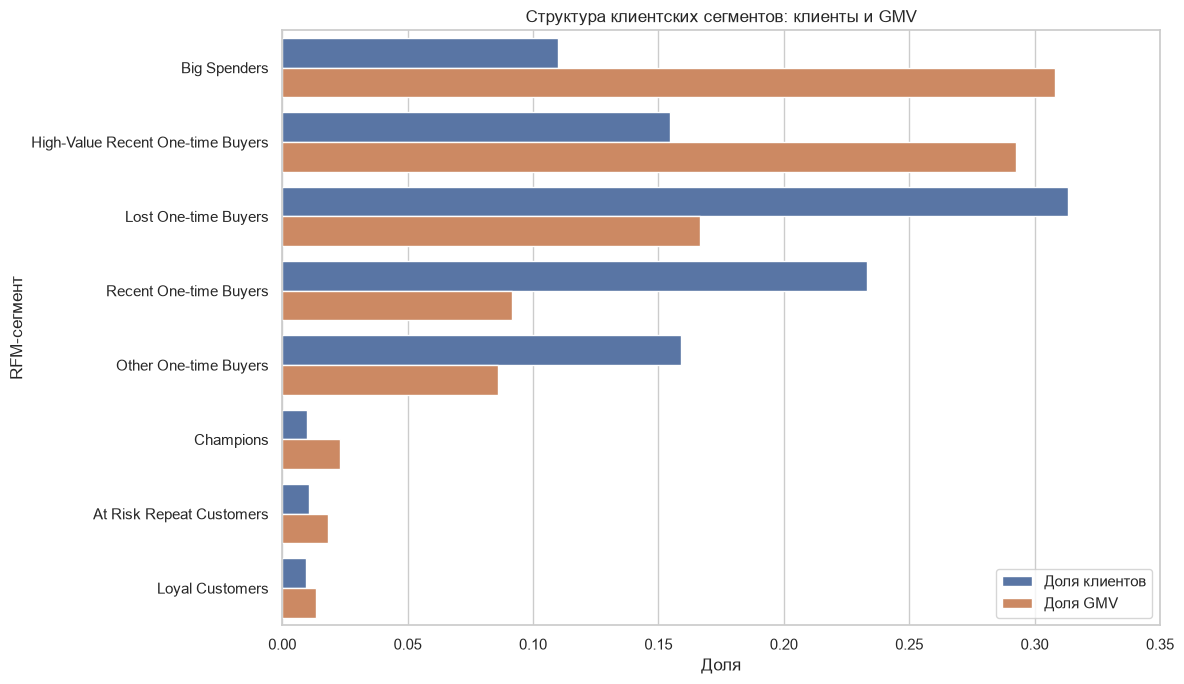

In [20]:
rfm_segment_plot = (
    rfm_segment_summary[
        ["segment", "customer_share", "gmv_share"]
    ]
    .melt(
        id_vars="segment",
        var_name="metric",
        value_name="share",
    )
)

rfm_segment_plot["metric"] = (
    rfm_segment_plot["metric"]
    .map(
        {
            "customer_share": "Доля клиентов",
            "gmv_share": "Доля GMV",
        }
    )
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=rfm_segment_plot,
    x="share",
    y="segment",
    hue="metric",
)

plt.title("Структура клиентских сегментов: клиенты и GMV")
plt.xlabel("Доля")
plt.ylabel("RFM-сегмент")
plt.xlim(0, 0.35)
plt.legend(title="")
plt.tight_layout()
plt.show()

### Интерпретация клиентского анализа

Клиентская база Olist характеризуется крайне низкой повторностью покупок: только около **3% клиентов** совершили более одного доставленного заказа. Поэтому классические RFM-подходы были адаптированы под структуру данных с преобладанием разовых покупателей.

Медианный LTV proxy, рассчитанный как накопленный GMV клиента за доступный период наблюдения, составил **89,73**. При этом верхние 10% клиентов сформировали около **41,14% GMV**, что указывает на заметную концентрацию товарного оборота среди наиболее дорогих покупателей.

Сегменты `Big Spenders` и `High-Value Recent One-time Buyers` вместе составляют около **26% клиентской базы**, но формируют примерно **60% GMV**. Это показывает, что для маркетплейса важны не только повторные покупатели, но и дорогие клиенты, совершившие пока только один заказ.

Сегмент `Lost One-time Buyers` является крупнейшим — около **31% клиентов**. Эти покупатели давно не совершали заказов и имеют сравнительно невысокий накопленный GMV. Массовая реактивация такого сегмента может быть экономически неэффективной, поэтому коммуникации следует приоритизировать по потенциальной ценности клиента.

Повторные сегменты — `Champions`, `Loyal Customers` и `At Risk Repeat Customers` — вместе составляют лишь небольшую часть клиентской базы. Особенно важен сегмент `At Risk Repeat Customers`: эти клиенты уже демонстрировали повторное поведение, но давно не совершали покупок, поэтому могут быть более перспективной аудиторией для реактивации, чем разовые покупатели.

Следует учитывать, что LTV здесь является только proxy-метрикой: в данных отсутствуют маржа, комиссия маркетплейса, расходы на привлечение и полный жизненный цикл клиента.

### Cohort retention

Когорта определяется как месяц первой доставленной покупки клиента. Retention показывает, какая доля клиентов из каждой когорты совершила хотя бы одну повторную покупку через определённое количество месяцев.

Перед визуализацией клиентские данные приводятся к уровню `customer_unique_id × order_month`. Это предотвращает повторный учёт клиента, если он совершил несколько заказов в одном месяце.

Пустые ячейки будущих периодов не заменяются нулями: отсутствие доступного периода наблюдения не означает отсутствие повторной покупки.

In [21]:
customer_months = (
    delivered_orders[
        [
            "customer_unique_id",
            "order_month",
        ]
    ]
    .drop_duplicates()
    .copy()
)

customer_months["cohort_month"] = (
    customer_months
    .groupby("customer_unique_id")["order_month"]
    .transform("min")
)

customer_months["cohort_index"] = (
    (
        customer_months["order_month"].dt.year
        - customer_months["cohort_month"].dt.year
    ) * 12
    + (
        customer_months["order_month"].dt.month
        - customer_months["cohort_month"].dt.month
    )
)

cohort_counts = (
    customer_months
    .groupby(
        [
            "cohort_month",
            "cohort_index",
        ]
    )["customer_unique_id"]
    .nunique()
    .unstack()
    .sort_index()
)

cohort_sizes = cohort_counts[0]

retention_matrix = cohort_counts.div(
    cohort_sizes,
    axis=0,
)

cohort_size_table = (
    cohort_sizes
    .rename("cohort_size")
    .to_frame()
)

display(cohort_size_table)
display(retention_matrix.iloc[:, :7])

,cohort_size
cohort_month,
2016-09-01,1.00
2016-10-01,262.00
2016-12-01,1.00
2017-01-01,717.00
2017-02-01,"1,628.00"
2017-03-01,"2,503.00"
2017-04-01,"2,256.00"
2017-05-01,"3,451.00"
2017-06-01,"3,037.00"


cohort_index,0,1,2,3,4,5,6
cohort_month,,,,,,,
2016-09-01,1.00,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,1.00,NaN,NaN,NaN,NaN,NaN,0.00
2016-12-01,1.00,1.00,NaN,NaN,NaN,NaN,NaN
2017-01-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-02-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-03-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-04-01,1.00,0.01,0.00,0.00,0.00,0.00,0.00
2017-05-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-06-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00


In [22]:
customer_months = (
    delivered_orders[
        [
            "customer_unique_id",
            "order_month",
        ]
    ]
    .drop_duplicates()
    .copy()
)

customer_months["cohort_month"] = (
    customer_months
    .groupby("customer_unique_id")["order_month"]
    .transform("min")
)

customer_months["cohort_index"] = (
    (
        customer_months["order_month"].dt.year
        - customer_months["cohort_month"].dt.year
    ) * 12
    + (
        customer_months["order_month"].dt.month
        - customer_months["cohort_month"].dt.month
    )
)

max_observation_month = customer_months["order_month"].max()

cohort_counts_raw = (
    customer_months
    .groupby(
        [
            "cohort_month",
            "cohort_index",
        ]
    )["customer_unique_id"]
    .nunique()
    .unstack()
    .sort_index()
)

max_available_index = int(
    (
        max_observation_month.year
        - cohort_counts_raw.index.min().year
    ) * 12
    + (
        max_observation_month.month
        - cohort_counts_raw.index.min().month
    )
)

cohort_counts_raw = cohort_counts_raw.reindex(
    columns=range(max_available_index + 1)
)

available_months = (
    (
        max_observation_month.year
        - cohort_counts_raw.index.year
    ) * 12
    + (
        max_observation_month.month
        - cohort_counts_raw.index.month
    )
).to_numpy()

observed_mask = (
    np.arange(cohort_counts_raw.shape[1])[None, :]
    <= available_months[:, None]
)

# В наблюдаемых периодах отсутствие повторов означает 0.
# Будущие периоды остаются NaN.
cohort_counts = (
    cohort_counts_raw
    .fillna(0)
    .where(observed_mask)
)

cohort_sizes = cohort_counts[0]

retention_matrix = cohort_counts.div(
    cohort_sizes,
    axis=0,
)

display(
    retention_matrix.iloc[:, :7].style.format(
        "{:.2%}",
        na_rep="—",
    )
)

cohort_index,0,1,2,3,4,5,6
cohort_month,,,,,,,
2016-09-01 00:00:00,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
2016-10-01 00:00:00,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.38%
2016-12-01 00:00:00,100.00%,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%
2017-01-01 00:00:00,100.00%,0.28%,0.28%,0.14%,0.42%,0.14%,0.42%
2017-02-01 00:00:00,100.00%,0.18%,0.31%,0.12%,0.43%,0.12%,0.25%
2017-03-01 00:00:00,100.00%,0.44%,0.36%,0.40%,0.36%,0.16%,0.16%
2017-04-01 00:00:00,100.00%,0.62%,0.22%,0.18%,0.27%,0.27%,0.35%
2017-05-01 00:00:00,100.00%,0.46%,0.46%,0.29%,0.29%,0.32%,0.41%
2017-06-01 00:00:00,100.00%,0.49%,0.40%,0.43%,0.30%,0.40%,0.36%


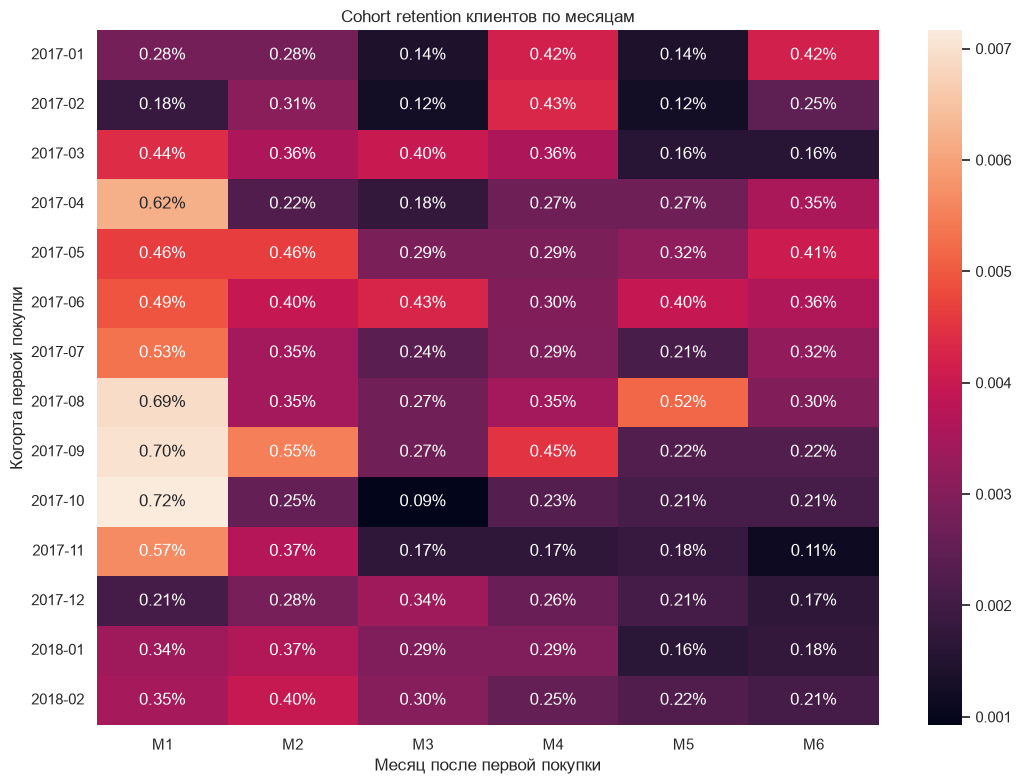

In [23]:
cohort_mask = (
    (retention_matrix.index >= pd.Timestamp("2017-01-01"))
    & (retention_matrix.index <= pd.Timestamp("2018-02-01"))
)

retention_heatmap = retention_matrix.loc[
    cohort_mask,
    1:6,
].copy()

retention_heatmap.index = (
    retention_heatmap.index.strftime("%Y-%m")
)

retention_heatmap.columns = [
    f"M{month}"
    for month in retention_heatmap.columns
]

plt.figure(figsize=(11, 8))

sns.heatmap(
    retention_heatmap,
    annot=True,
    fmt=".2%",
)

plt.title("Cohort retention клиентов по месяцам")
plt.xlabel("Месяц после первой покупки")
plt.ylabel("Когорта первой покупки")
plt.tight_layout()
plt.show()

### Интерпретация cohort retention

Когортный анализ подтверждает крайне низкую повторность покупок. В первый месяц после первоначального заказа возвращается примерно **0,2–0,7% клиентов**, а в последующие месяцы retention обычно остаётся ниже **0,5%**.

Ни одна из крупных когорт не демонстрирует устойчивого улучшения удержания. Отдельные более высокие значения являются небольшими колебаниями, а не признаком стабильного роста повторных покупок.

Важно, что показатели M1–M6 отражают покупки клиентов в конкретном месяце после первой покупки, а не накопительную долю всех когда-либо вернувшихся клиентов.

Полученный результат согласуется с общей долей повторных клиентов около **3%**. Для Olist в доступном периоде наблюдения характерна модель преимущественно разовых покупок, поэтому продуктовой команде важно:

- анализировать причины отсутствия повторного заказа;
- разрабатывать сценарии второй покупки;
- приоритизировать реактивацию ценных разовых покупателей;
- отдельно работать с небольшим сегментом клиентов, которые уже совершали повторные заказы.

При интерпретации необходимо учитывать ограниченный горизонт данных и отсутствие информации о покупках клиентов за пределами платформы и после завершения периода наблюдения.

## 7. Seller Marketing Funnel и ценность продавцов

В отличие от клиентского анализа, Marketing Funnel by Olist описывает воронку привлечения продавцов:

**MQL → Closed Deal → Seller with Orders → Seller GMV**

Цель анализа — сравнить маркетинговые каналы не только по конверсии лидов в закрытые сделки, но и по последующей активации продавцов и их вкладу в GMV.

In [24]:
print("Колонки funnel_seller_value:")
display(pd.Series(funnel_seller_value.columns, name="column"))

display(funnel_seller_value.head())

Колонки funnel_seller_value:


0                          mql_id
1                       seller_id
2                        won_date
3                   seller_orders
4              seller_order_items
5                first_order_date
6                 last_order_date
7                delivered_orders
8                      seller_gmv
9                  seller_freight
10                unique_products
11    has_post_acquisition_orders
12           has_delivered_orders
13            days_to_first_order
14                         origin
15                   origin_group
16             first_contact_date
17                landing_page_id
18               business_segment
19                      lead_type
20         lead_behaviour_profile
21                  business_type
22                  days_to_close
23            days_to_close_valid
Name: column, dtype: str

,mql_id,seller_id,won_date,seller_orders,seller_order_items,first_order_date,last_order_date,delivered_orders,seller_gmv,seller_freight,unique_products,has_post_acquisition_orders,has_delivered_orders,days_to_first_order,origin,origin_group,first_contact_date,landing_page_id,business_segment,lead_type,lead_behaviour_profile,business_type,days_to_close,days_to_close_valid
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,2018-02-26 19:58:54,3.00,3.00,2018-06-20 21:40:18,2018-07-23 20:50:50,3.00,858.00,72.17,3.00,True,True,114.07,organic_search,organic_search,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,pet,online_medium,cat,reseller,5.83,5.83
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,2018-05-08 20:17:59,0.00,0.00,NaN,NaN,0.00,0.00,0.00,0.00,False,False,NaN,referral,referral,2018-04-04,2f08471dfb83baef522f952438a36f6e,car_accessories,industry,eagle,reseller,34.85,34.85
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,2018-06-05 17:27:23,107.00,110.00,2018-06-11 14:32:25,2018-08-22 10:02:13,107.00,"23,065.02","2,307.06",48.00,True,True,5.88,organic_search,organic_search,2018-04-03,1ceb590cd1e00c7ee95220971f82693d,home_appliances,online_big,cat,reseller,63.73,63.73
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,2018-01-17 13:51:03,0.00,0.00,NaN,NaN,0.00,0.00,0.00,0.00,False,False,NaN,paid_search,paid_search,2018-01-14,22c29808c4f815213303f8933030604c,food_drink,online_small,NaN,reseller,3.58,3.58
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,2018-07-03 20:17:45,15.00,17.00,2018-07-19 15:36:35,2018-08-27 12:39:11,15.00,573.50,242.71,10.00,True,True,15.80,unknown,unknown,2017-10-09,a0fbc0263cb98bdb0d72b9f9f283a172,home_appliances,industry,wolf,manufacturer,267.85,267.85


In [25]:
mql = pd.read_csv(
    project_root
    / "data"
    / "raw"
    / "olist_marketing_qualified_leads_dataset.csv"
)

total_mql = mql["mql_id"].nunique()
closed_deals = funnel_seller_value["mql_id"].nunique()

activated_sellers = (
    funnel_seller_value["has_post_acquisition_orders"].sum()
)

sellers_with_delivered_orders = (
    funnel_seller_value["has_delivered_orders"].sum()
)

delivered_sellers = funnel_seller_value.loc[
    funnel_seller_value["has_delivered_orders"]
].copy()

seller_funnel_metrics = pd.DataFrame(
    {
        "Метрика": [
            "Marketing Qualified Leads",
            "Closed Deals",
            "Конверсия MQL → Closed Deal",
            "Продавцы с заказами после привлечения",
            "Activation rate после сделки",
            "Продавцы с доставленными заказами",
            "Медианное время до первого заказа, дней",
            "Медианный seller GMV",
            "Средний seller GMV",
        ],
        "Значение": [
            f"{total_mql:,.0f}",
            f"{closed_deals:,.0f}",
            f"{closed_deals / total_mql:.2%}",
            f"{activated_sellers:,.0f}",
            f"{activated_sellers / closed_deals:.2%}",
            f"{sellers_with_delivered_orders:,.0f}",
            (
                f"{funnel_seller_value['days_to_first_order'].median():,.1f}"
            ),
            f"{delivered_sellers['seller_gmv'].median():,.2f}",
            f"{delivered_sellers['seller_gmv'].mean():,.2f}",
        ],
    }
)

seller_funnel_metrics

,Метрика,Значение
0,Marketing Qualified Leads,"8,000"
1,Closed Deals,842
2,Конверсия MQL → Closed Deal,10.53%
3,Продавцы с заказами после привлечения,380
4,Activation rate после сделки,45.13%
5,Продавцы с доставленными заказами,376
6,"Медианное время до первого заказа, дней",44.3
7,Медианный seller GMV,547.40
8,Средний seller GMV,"1,768.24"


### Методология seller funnel

Верхний уровень воронки рассчитывается по всем маркетинговым лидам. Последующие этапы определяются по закрытым сделкам, связанным с конкретным `seller_id`.

Продавец считается активированным, если после закрытия сделки у него появился хотя бы один заказ. Отдельно выделяются продавцы с доставленными заказами, поскольку именно они формируют реализованный seller GMV.

Seller GMV — это стоимость проданных товаров привлечённого продавца, а не выручка или прибыль маркетплейса. Без данных о комиссии и маркетинговых расходах нельзя рассчитать настоящий revenue, CAC или ROMI.

In [26]:
mql_by_channel = (
    mql
    .assign(
        origin_group=(
            mql["origin"]
            .fillna("unknown")
            .replace("", "unknown")
        )
    )
    .groupby("origin_group", as_index=False)
    .agg(
        mql_count=("mql_id", "nunique"),
    )
)

closed_deals_by_channel = (
    funnel_seller_value
    .groupby("origin_group", as_index=False)
    .agg(
        closed_deals=("mql_id", "nunique"),
        activated_sellers=("has_post_acquisition_orders", "sum"),
        sellers_with_delivered_orders=("has_delivered_orders", "sum"),
        total_seller_gmv=("seller_gmv", "sum"),
        median_days_to_first_order=("days_to_first_order", "median"),
    )
)

median_gmv_by_channel = (
    funnel_seller_value.loc[
        funnel_seller_value["has_delivered_orders"]
    ]
    .groupby("origin_group", as_index=False)
    .agg(
        median_seller_gmv=("seller_gmv", "median"),
    )
)

channel_summary = (
    mql_by_channel
    .merge(
        closed_deals_by_channel,
        on="origin_group",
        how="left",
        validate="one_to_one",
    )
    .merge(
        median_gmv_by_channel,
        on="origin_group",
        how="left",
        validate="one_to_one",
    )
)

count_columns = [
    "closed_deals",
    "activated_sellers",
    "sellers_with_delivered_orders",
]

channel_summary[count_columns] = (
    channel_summary[count_columns].fillna(0)
)

channel_summary["mql_to_closed_deal_rate"] = (
    channel_summary["closed_deals"]
    / channel_summary["mql_count"]
)

channel_summary["activation_rate"] = np.where(
    channel_summary["closed_deals"] > 0,
    channel_summary["activated_sellers"]
    / channel_summary["closed_deals"],
    np.nan,
)

channel_summary["mql_to_delivered_seller_rate"] = (
    channel_summary["sellers_with_delivered_orders"]
    / channel_summary["mql_count"]
)

channel_summary = (
    channel_summary
    .sort_values("total_seller_gmv", ascending=False)
    .reset_index(drop=True)
)

channel_summary

,origin_group,mql_count,closed_deals,activated_sellers,sellers_with_delivered_orders,total_seller_gmv,median_days_to_first_order,median_seller_gmv,mql_to_closed_deal_rate,activation_rate,mql_to_delivered_seller_rate
0,unknown,1159,179,81,80,"209,651.37",42.09,611.73,0.15,0.45,0.07
1,organic_search,2296,271,113,111,"204,509.79",44.35,560.00,0.12,0.42,0.05
2,paid_search,1586,195,101,100,"151,444.15",44.70,515.60,0.12,0.52,0.06
3,social,1350,75,31,31,"43,394.20",42.69,722.20,0.06,0.41,0.02
4,direct_traffic,499,56,31,31,"21,852.90",49.41,399.00,0.11,0.55,0.06
5,referral,284,24,9,9,"16,578.25",28.94,"1,368.50",0.08,0.38,0.03
6,email,493,15,6,6,"8,484.99",51.82,338.20,0.03,0.40,0.01
7,other,150,4,2,2,"6,776.75",55.38,"3,388.38",0.03,0.50,0.01
8,display,118,6,2,2,923.00,80.41,461.50,0.05,0.33,0.02
9,other_publicities,65,3,0,0,0.00,NaN,NaN,0.05,0.00,0.00


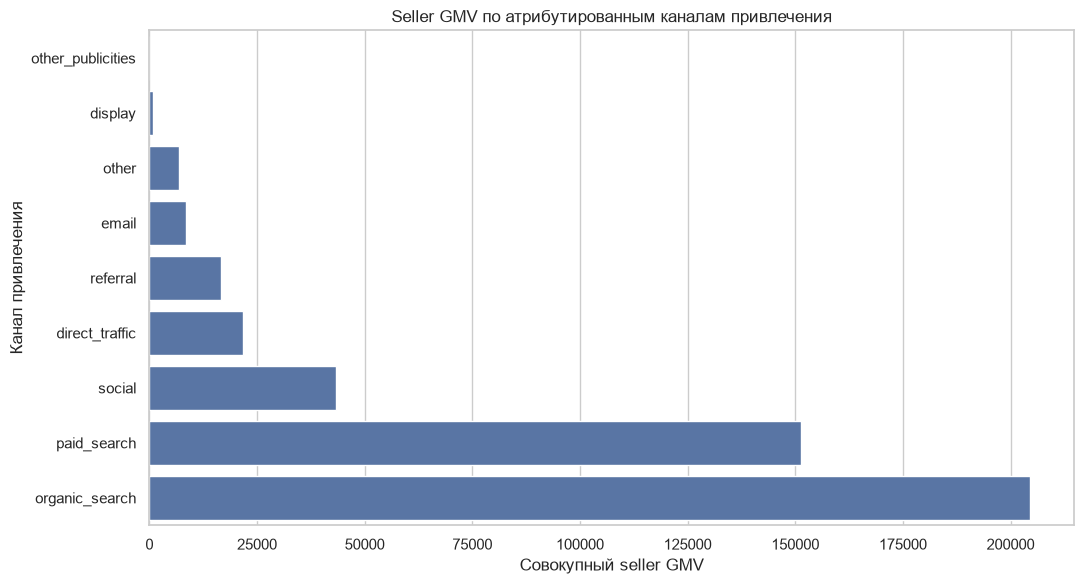

In [27]:
attributed_channels = (
    channel_summary.loc[
        ~channel_summary["origin_group"].eq("unknown")
    ]
    .copy()
)

channel_gmv_plot = (
    attributed_channels
    .sort_values("total_seller_gmv")
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=channel_gmv_plot,
    x="total_seller_gmv",
    y="origin_group",
)

plt.title("Seller GMV по атрибутированным каналам привлечения")
plt.xlabel("Совокупный seller GMV")
plt.ylabel("Канал привлечения")
plt.tight_layout()
plt.show()

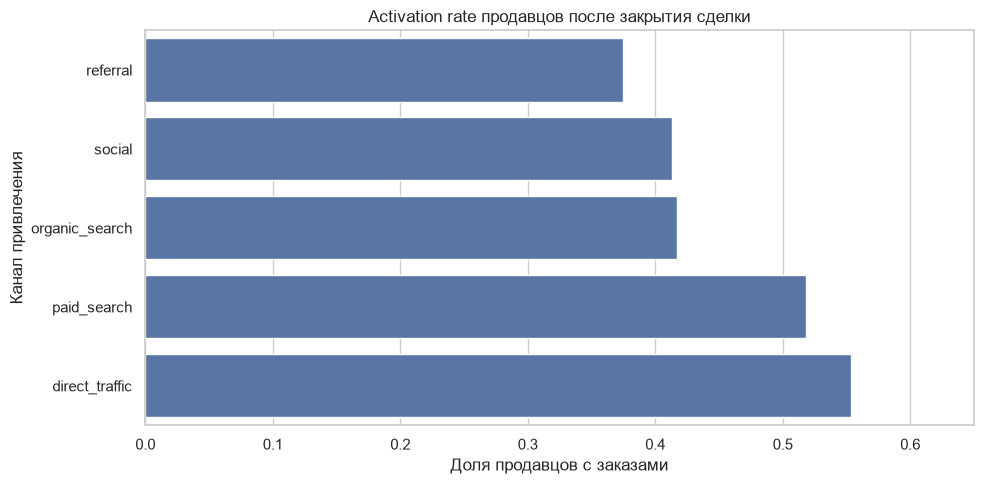

In [28]:
activation_plot = (
    attributed_channels.loc[
        attributed_channels["closed_deals"] >= 20
    ]
    .sort_values("activation_rate")
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=activation_plot,
    x="activation_rate",
    y="origin_group",
)

plt.title("Activation rate продавцов после закрытия сделки")
plt.xlabel("Доля продавцов с заказами")
plt.ylabel("Канал привлечения")
plt.xlim(0, 0.65)
plt.tight_layout()
plt.show()

### Интерпретация каналов привлечения продавцов

Среди атрибутированных каналов `organic_search` привёл наибольшее количество закрытых сделок, активированных продавцов и сформировал наибольший совокупный seller GMV — около **204,5 тыс.**

`paid_search` уступает органическому поиску по совокупному GMV, но показывает более высокую активацию после закрытия сделки: около **52%** продавцов получили заказы против примерно **42%** у `organic_search`.

Канал `social` сформировал значительный объём MQL, однако его конверсия в закрытую сделку составила только около **6%**, а итоговая доля активированных продавцов от всех лидов — около **2%**. Это может указывать на более низкое качество или меньшую готовность социальных лидов к началу продаж.

`direct_traffic` показал высокую activation rate — около **55%**, но относительно низкий совокупный и медианный seller GMV. Следовательно, высокая активация сама по себе не гарантирует высокую ценность привлечённых продавцов.

У `referral` медианный seller GMV составляет около **1 368,50**, однако результат основан только на девяти продавцах с доставленными заказами. Поэтому канал выглядит перспективно, но требует подтверждения на большей выборке.

Источник `unknown` сформировал значительный объём сделок и seller GMV, но не рассматривается как отдельный маркетинговый канал. Высокая доля неатрибутированных лидов ограничивает точность сравнения и указывает на необходимость улучшения marketing attribution.

Главный вывод: каналы seller acquisition необходимо оценивать по всей цепочке — от MQL и закрытой сделки до фактической активации и последующего GMV продавца. Без данных о рекламных расходах нельзя определить CAC, ROMI и экономическую эффективность каналов.

## 8. ML-модель риска негативного клиентского опыта

В рамках проекта была построена модель для прогнозирования риска негативного отзыва по доставленному заказу.

Целевая переменная определялась следующим образом:

- `bad_review = 1`, если `review_score <= 3`;
- `bad_review = 0`, если `review_score >= 4`.

Модель рассматривается не как инструмент автоматического принятия решений, а как механизм приоритизации заказов для клиентской поддержки и операционного контроля.

Для снижения риска переоценки качества использовалось временное разделение данных: модель обучалась на более раннем периоде и проверялась на будущих заказах. Признаки, возникающие после формирования отзыва, были исключены для предотвращения утечки целевой переменной.

In [29]:
print("Колонки model_results:")
display(pd.Series(model_results.columns, name="column"))

display(model_results)

Колонки model_results:


0                         model
1                     threshold
2                       roc_auc
3                        pr_auc
4                    lift_at_10
5        top_10_bad_review_rate
6                      accuracy
7                     precision
8                        recall
9                            f1
10     predicted_positive_share
11    predicted_positive_orders
12                  test_orders
13         test_bad_review_rate
Name: column, dtype: str

,model,threshold,roc_auc,pr_auc,lift_at_10,top_10_bad_review_rate,accuracy,precision,recall,f1,predicted_positive_share,predicted_positive_orders,test_orders,test_bad_review_rate
0,Logistic Regression,0.30,0.65,0.34,2.65,0.44,0.84,0.52,0.20,0.29,0.06,1198,18526,0.17
1,CatBoost,0.30,0.65,0.36,2.68,0.44,0.84,0.57,0.20,0.30,0.06,1089,18526,0.17


In [30]:
model_comparison_display = pd.DataFrame(
    {
        "Модель": model_results["model"],
        "ROC-AUC": model_results["roc_auc"].map("{:.3f}".format),
        "PR-AUC": model_results["pr_auc"].map("{:.3f}".format),
        "Lift@10%": model_results["lift_at_10"].map("{:.2f}".format),
        "Precision": model_results["precision"].map("{:.2%}".format),
        "Recall": model_results["recall"].map("{:.2%}".format),
        "F1-score": model_results["f1"].map("{:.3f}".format),
        "Доля bad review в top-10%": (
            model_results["top_10_bad_review_rate"]
            .map("{:.2%}".format)
        ),
    }
)

model_comparison_display

,Модель,ROC-AUC,PR-AUC,Lift@10%,Precision,Recall,F1-score,Доля bad review в top-10%
0,Logistic Regression,0.649,0.344,2.65,52.42%,20.44%,0.294,44.01%
1,CatBoost,0.650,0.364,2.68,56.57%,20.05%,0.296,44.49%


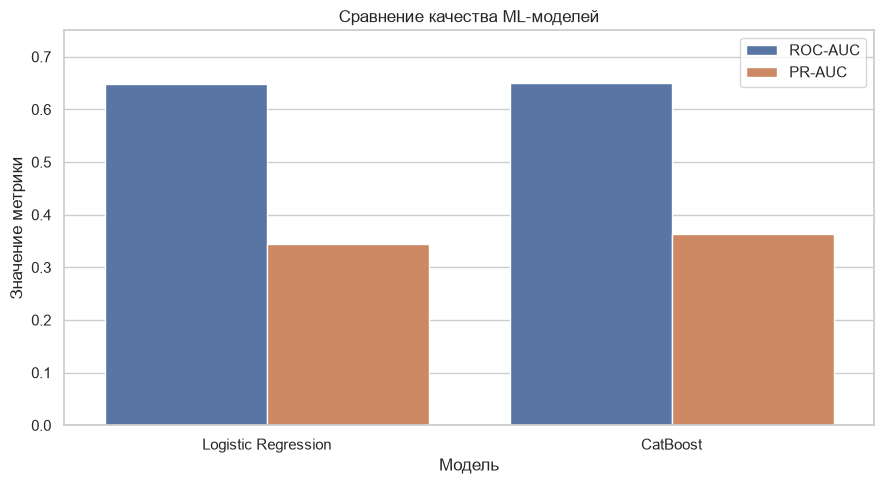

In [31]:
model_quality_plot = (
    model_results[
        [
            "model",
            "roc_auc",
            "pr_auc",
        ]
    ]
    .melt(
        id_vars="model",
        var_name="metric",
        value_name="value",
    )
)

model_quality_plot["metric"] = (
    model_quality_plot["metric"]
    .map(
        {
            "roc_auc": "ROC-AUC",
            "pr_auc": "PR-AUC",
        }
    )
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_quality_plot,
    x="model",
    y="value",
    hue="metric",
)

plt.title("Сравнение качества ML-моделей")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.ylim(0, 0.75)
plt.legend(title="")
plt.tight_layout()
plt.show()

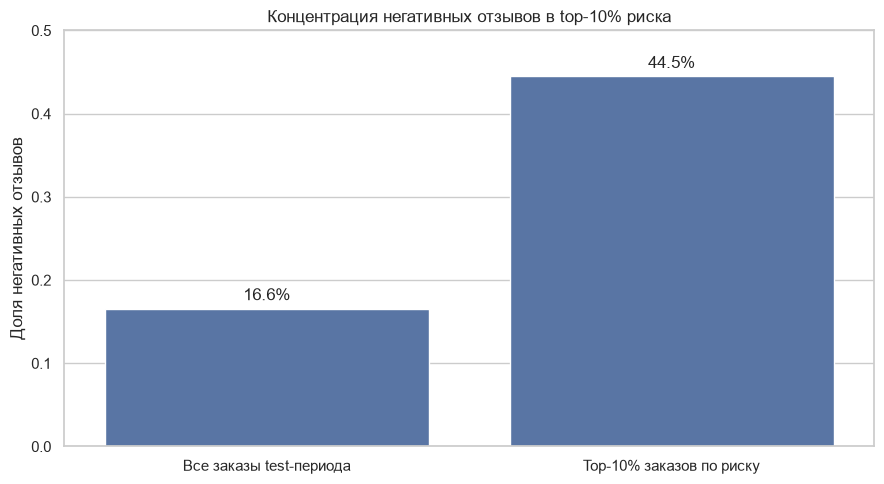

In [32]:
catboost_result = (
    model_results.loc[
        model_results["model"].eq("CatBoost")
    ]
    .iloc[0]
)

risk_concentration = pd.DataFrame(
    {
        "Сегмент заказов": [
            "Все заказы test-периода",
            "Top-10% заказов по риску",
        ],
        "Доля негативных отзывов": [
            catboost_result["test_bad_review_rate"],
            catboost_result["top_10_bad_review_rate"],
        ],
    }
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_concentration,
    x="Сегмент заказов",
    y="Доля негативных отзывов",
)

plt.title("Концентрация негативных отзывов в top-10% риска")
plt.xlabel("")
plt.ylabel("Доля негативных отзывов")
plt.ylim(0, 0.50)

for index, value in enumerate(
    risk_concentration["Доля негативных отзывов"]
):
    plt.text(
        index,
        value + 0.01,
        f"{value:.1%}",
        ha="center",
    )

plt.tight_layout()
plt.show()

### Интерпретация результатов модели

CatBoost показал лишь небольшое преимущество над Logistic Regression по ROC-AUC, однако улучшил более значимые для несбалансированной задачи показатели:

- PR-AUC вырос с **0,344** до **0,364**;
- precision увеличился с **52,42%** до **56,57%**;
- lift@10% вырос с **2,65** до **2,68**.

Средняя доля негативных отзывов на тестовом периоде составляла около **16,6%**. Среди 10% заказов с максимальным прогнозируемым риском она достигла **44,49%**.

Таким образом, модель концентрирует негативные случаи примерно в **2,68 раза эффективнее случайного отбора**. Это позволяет использовать её для ранжирования заказов, когда ресурс клиентской поддержки ограничен и невозможно обработать все обращения.

Основными факторами риска по результатам feature importance и SHAP-анализа стали:

- задержка относительно обещанной даты;
- фактическая длительность доставки;
- количество товарных позиций;
- количество продавцов;
- сложность состава заказа.

Модель не следует интерпретировать как точный прогноз каждого негативного отзыва. ROC-AUC около **0,65** указывает на умеренную разделяющую способность, поэтому основная ценность модели заключается в приоритизации наиболее рискованных заказов.

Текущая версия работает после завершения доставки. Для практического внедрения более полезной следующей итерацией стала бы модель раннего предупреждения, использующая только признаки, доступные в момент оформления и исполнения заказа.

## 9. Продуктовые гипотезы и симуляция A/B-теста

Наблюдательный анализ использовался для выявления факторов, связанных с негативным клиентским опытом, и формулирования продуктовых гипотез.

Были проверены три зависимости:

1. связь задержки относительно обещанной даты с негативным отзывом;
2. связь multi-seller заказов с негативным отзывом;
3. связь абсолютной продолжительности доставки с клиентской оценкой.

Поскольку в данных отсутствуют реальные экспериментальные группы, A/B-анализ выполнен в форме синтетической симуляции. Он демонстрирует проектирование эксперимента, расчёт размера выборки и интерпретацию результата, но не является доказательством эффекта реального продуктового изменения.

In [33]:
hypotheses_summary = pd.DataFrame(
    {
        "Гипотеза": [
            "Задержка доставки",
            "Несколько продавцов в заказе",
            "Доставка 15+ дней без просрочки",
        ],
        "Базовая доля bad review": [
            0.1734,
            0.2053,
            0.1372,
        ],
        "Доля bad review в риск-сегменте": [
            0.7325,
            0.6059,
            0.2360,
        ],
        "Абсолютная разница, п.п.": [
            55.91,
            40.05,
            9.88,
        ],
        "Относительный риск": [
            4.22,
            2.95,
            1.72,
        ],
    }
)

hypotheses_display = hypotheses_summary.copy()

hypotheses_display["Базовая доля bad review"] = (
    hypotheses_display["Базовая доля bad review"]
    .map("{:.2%}".format)
)

hypotheses_display["Доля bad review в риск-сегменте"] = (
    hypotheses_display["Доля bad review в риск-сегменте"]
    .map("{:.2%}".format)
)

hypotheses_display

,Гипотеза,Базовая доля bad review,Доля bad review в риск-сегменте,"Абсолютная разница, п.п.",Относительный риск
0,Задержка доставки,17.34%,73.25%,55.91,4.22
1,Несколько продавцов в заказе,20.53%,60.59%,40.05,2.95
2,Доставка 15+ дней без просрочки,13.72%,23.60%,9.88,1.72


In [34]:
ab_simulation_summary = pd.DataFrame(
    {
        "Показатель": [
            "Базовая доля негативных отзывов",
            "Минимальный обнаруживаемый эффект",
            "Размер выборки на группу",
            "Размер выборки всего",
            "Доля bad review в control",
            "Доля bad review в test",
            "Абсолютное снижение",
            "Относительное снижение",
            "p-value",
            "95%-й доверительный интервал",
            "Эмпирическая мощность",
        ],
        "Значение": [
            "21.06%",
            "2.00 п.п.",
            "6,293",
            "12,586",
            "20.63%",
            "18.54%",
            "2.08 п.п.",
            "10.09%",
            "0.0033",
            "[0.70; 3.47] п.п.",
            "81.55%",
        ],
    }
)

ab_simulation_summary

,Показатель,Значение
0,Базовая доля негативных отзывов,21.06%
1,Минимальный обнаруживаемый эффект,2.00 п.п.
2,Размер выборки на группу,"6,293"
3,Размер выборки всего,"12,586"
4,Доля bad review в control,20.63%
5,Доля bad review в test,18.54%
6,Абсолютное снижение,2.08 п.п.
7,Относительное снижение,10.09%
8,p-value,0.0033
9,95%-й доверительный интервал,[0.70; 3.47] п.п.


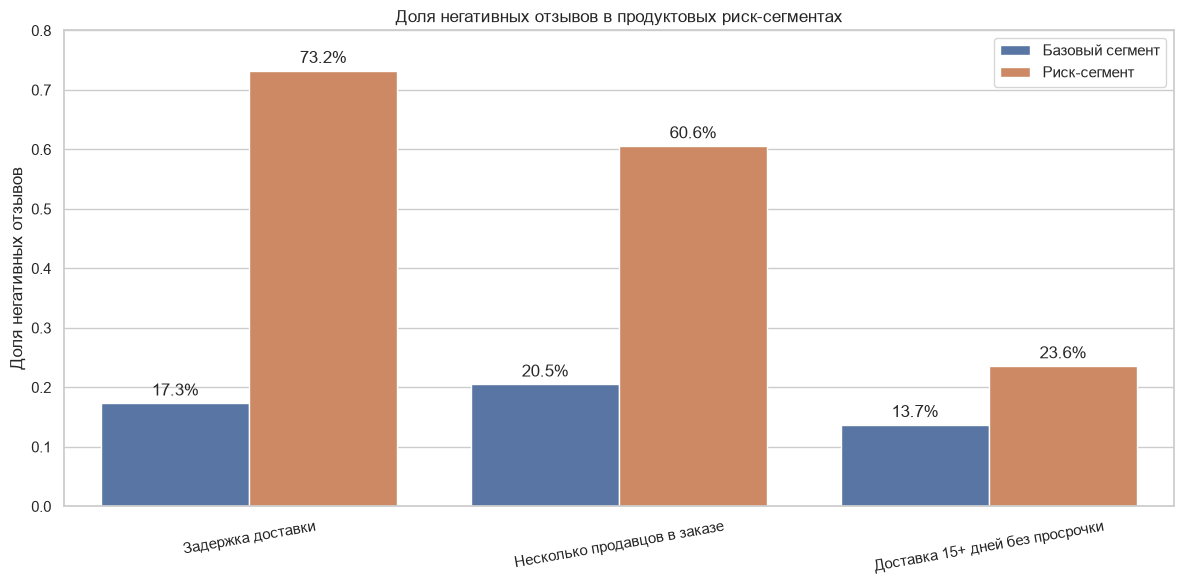

In [35]:
hypotheses_plot = (
    hypotheses_summary[
        [
            "Гипотеза",
            "Базовая доля bad review",
            "Доля bad review в риск-сегменте",
        ]
    ]
    .melt(
        id_vars="Гипотеза",
        var_name="Группа",
        value_name="bad_review_rate",
    )
)

hypotheses_plot["Группа"] = hypotheses_plot["Группа"].map(
    {
        "Базовая доля bad review": "Базовый сегмент",
        "Доля bad review в риск-сегменте": "Риск-сегмент",
    }
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=hypotheses_plot,
    x="Гипотеза",
    y="bad_review_rate",
    hue="Группа",
)

plt.title("Доля негативных отзывов в продуктовых риск-сегментах")
plt.xlabel("")
plt.ylabel("Доля негативных отзывов")
plt.ylim(0, 0.80)
plt.xticks(rotation=10)
plt.legend(title="")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value:.1%}" for value in container.datavalues],
        padding=3,
    )

plt.tight_layout()
plt.show()

### Интерпретация гипотез и A/B simulation

Наиболее сильная наблюдаемая связь обнаружена для задержки доставки. Среди заказов, доставленных без опоздания, доля негативных отзывов составляла **17,34%**, а среди задержанных — **73,25%**. Относительный риск негативного отзыва был примерно в **4,22 раза выше**.

Multi-seller заказы также образуют выраженный риск-сегмент: доля негативных отзывов достигает **60,59%** против **20,53%** у заказов одного продавца. Связь сохранялась и после исключения задержанных заказов, поэтому она может быть обусловлена не только сроками, но и сложностью исполнения: несколькими отправлениями, частичной доставкой или несогласованностью статусов.

Даже при соблюдении обещанной даты длительное ожидание связано с ухудшением клиентского опыта. Для доставки продолжительностью 15 дней и более доля негативных отзывов составила **23,60%**, тогда как для заказов, доставленных не более чем за шесть дней, — **13,72%**.

Эти результаты не доказывают причинно-следственную связь. На оценки также могут влиять категория товара, регион, продавец, качество товара, стоимость доставки и другие характеристики заказа.

Для проверки продуктовой механики проактивного информирования была проведена синтетическая симуляция A/B-теста. При базовой доле негативных отзывов **21,06%** и минимальном обнаруживаемом эффекте **2 процентных пункта** потребовалось **6 293 наблюдения на группу**.

В воспроизводимом запуске симуляции доля негативных отзывов снизилась с **20,63%** в control до **18,54%** в test. Абсолютное снижение составило **2,08 процентного пункта**, `p-value = 0,0033`, а доверительный интервал не включал ноль.

Однако этот результат существует только внутри заданного сценария симуляции. Он показывает корректность дизайна и расчёта размера выборки, но не подтверждает, что реальное уведомление обязательно даст такой же эффект.

При проведении настоящего эксперимента дополнительно необходимо контролировать guardrail-метрики:

- обращения в клиентскую поддержку;
- отмены заказов;
- отписки от уведомлений;
- стоимость коммуникаций;
- повторные покупки;
- GMV и долю доставленных заказов.

## 10. Итоговые бизнес-рекомендации

На основании продуктового, клиентского, seller-funnel и ML-анализа можно сформулировать следующие рекомендации.

### 1. Сфокусировать операционный контроль на логистическом обещании

Задержка относительно обещанной даты является наиболее сильным сигналом негативного клиентского опыта. Рекомендуется:

- выделять заказы, приближающиеся к обещанной дате доставки;
- автоматически повышать приоритет заказов с риском просрочки;
- проактивно информировать клиента при изменении ожидаемого срока;
- анализировать причины задержек по продавцам, категориям и регионам;
- отдельно контролировать заказы с задержкой на три дня и более.

### 2. Выделить multi-seller заказы в отдельный риск-сегмент

Заказы нескольких продавцов связаны с существенно более высокой долей негативных отзывов даже без просрочки доставки. Возможные направления улучшения:

- показывать статус каждого отправления внутри заказа;
- заранее объяснять клиенту, что товары могут прибыть отдельно;
- синхронизировать коммуникации разных продавцов;
- выявлять частичные доставки и потерянные товарные позиции;
- использовать количество продавцов как признак операционного риска.

### 3. Контролировать не только просрочку, но и абсолютное время ожидания

Даже своевременная доставка может восприниматься негативно, если ожидание слишком продолжительное. Рекомендуется:

- отслеживать заказы с длительностью доставки более двух недель;
- улучшать точность обещанного срока;
- тестировать более быстрые логистические сценарии для ценных заказов;
- учитывать продолжительность доставки при ранжировании клиентских рисков.

### 4. Приоритизировать коммерческий и операционный контроль категорий класса A

Около 81% GMV формируют 17 товарных категорий. Для них особенно важны:

- мониторинг GMV, заказов и среднего чека;
- контроль качества продавцов;
- отслеживание доставки и отзывов;
- отдельные SLA и алерты для проблемных категорий.

Категория `office_furniture` требует дополнительного анализа, поскольку сочетает высокий средний GMV на заказ, высокую долю доставки и низкую клиентскую оценку.

### 5. Развивать сценарии второй покупки

Повторные покупки совершают только около 3% клиентов. Вместо массовых одинаковых коммуникаций рекомендуется:

- тестировать механики второй покупки;
- персонализировать предложения по категории первого заказа;
- работать с `High-Value Recent One-time Buyers`;
- реактивировать `At Risk Repeat Customers`;
- не тратить одинаковые ресурсы на все группы разовых покупателей.

### 6. Использовать ML-модель для приоритизации, а не автоматических решений

CatBoost позволяет выделить top-10% заказов, где доля негативных отзывов достигает около 44,5% против 16,6% в среднем.

Практический сценарий:

- ранжировать заказы по вероятности негативного опыта;
- передавать наиболее рискованные случаи службе поддержки;
- комбинировать прогноз модели с операционными правилами;
- контролировать precision, lift и стоимость обработки;
- постепенно перейти к модели раннего предупреждения до завершения доставки.

### 7. Оценивать seller acquisition по полной воронке

Каналы привлечения продавцов следует сравнивать не только по закрытым сделкам, но и по:

- активации продавцов;
- времени до первого заказа;
- количеству доставленных заказов;
- seller GMV;
- устойчивости результата на достаточной выборке.

Для полноценной оценки эффективности необходимо дополнить данные маркетинговыми расходами и комиссией маркетплейса.

### 8. Проверять продуктовые изменения через контролируемые эксперименты

Проактивные уведомления о доставке являются обоснованной гипотезой для A/B-теста. Перед запуском необходимо заранее определить:

- основную метрику;
- MDE и необходимый размер выборки;
- длительность эксперимента;
- правила рандомизации;
- критерии остановки;
- guardrail-метрики;
- сегментный анализ результатов.

## 11. Ограничения анализа

Результаты проекта необходимо интерпретировать с учётом следующих ограничений данных:

- данные охватывают исторический период 2016–2018 годов;
- отсутствуют расходы на маркетинг и настоящий CAC;
- нет данных о комиссии, марже, себестоимости и прибыли маркетплейса;
- GMV отражает товарный оборот, а не выручку бизнеса;
- LTV рассчитан только как proxy через накопленный GMV;
- нет логов просмотров, кликов, корзины и пользовательских сессий;
- невозможно построить настоящую покупательскую воронку;
- Marketing Funnel относится к привлечению продавцов, а не покупателей;
- часть источников привлечения продавцов не атрибутирована;
- отсутствуют реальные экспериментальные группы;
- A/B simulation демонстрирует методологию, но не доказывает эффект продукта;
- наблюдательные зависимости не подтверждают причинно-следственную связь;
- ML-модель использует ограниченный набор доступных признаков;
- текущая модель оценивает риск после завершения доставки;
- отзывы отсутствуют для части заказов, что может создавать смещение;
- период наблюдения клиентов ограничен, поэтому повторные покупки и LTV могут быть недооценены.

Несмотря на ограничения, проект позволяет продемонстрировать полный аналитический цикл: от проверки качества данных и построения витрин до продуктовых выводов, ML-моделирования и дизайна эксперимента.

## 12. Навыки, продемонстрированные в проекте

В рамках проекта был реализован полный цикл аналитического исследования маркетплейса:

- проверка качества данных, ключей и уровней детализации таблиц;
- построение аналитических витрин без задвоения финансовых показателей;
- расчёт продуктовых и финансовых метрик: GMV, AOV, заказы, клиенты и стоимость доставки;
- анализ месячной динамики и товарных категорий;
- ABC-анализ категорий;
- cohort retention и анализ повторных покупок;
- адаптированная RFM-сегментация и расчёт LTV proxy;
- анализ seller acquisition funnel и ценности привлечённых продавцов;
- формулирование и проверка наблюдательных продуктовых гипотез;
- проектирование и симуляция A/B-теста;
- построение ML-пайплайна с временным разделением данных;
- контроль leakage и сравнение моделей по ROC-AUC, PR-AUC, F1 и lift@10%;
- интерпретация модели и перевод результатов в бизнес-сценарий;
- формулирование рекомендаций и ограничений анализа.

## Итог проекта

Проект показывает, что рост GMV Olist в доступном периоде был связан преимущественно с увеличением количества заказов, а не с устойчивым ростом среднего чека.

Клиентская база характеризуется низкой повторностью покупок: около 3% клиентов совершили более одного заказа. При этом верхние 10% клиентов сформировали около 41% GMV, а значительную роль играют дорогие разовые покупатели.

Основным операционным фактором негативного клиентского опыта является невыполнение логистического обещания. Задержки, длительная доставка и заказы нескольких продавцов образуют наиболее выраженные риск-сегменты.

ML-модель обладает умеренной общей точностью, но позволяет эффективно ранжировать заказы: в top-10% прогнозируемого риска доля негативных отзывов достигает около 44,5% против 16,6% в среднем.

Seller funnel показывает, что маркетинговые каналы необходимо оценивать не только по конверсии в закрытую сделку, но и по фактической активации продавцов и их последующему вкладу в GMV.

Главный результат проекта — не отдельная модель или метрика, а воспроизводимый end-to-end аналитический кейс, в котором технические расчёты связаны с бизнес-вопросами, ограничениями данных и возможными продуктовыми решениями.